In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex06_player_heatmap_after_masking', 'pitch_segmentation_model': 'lightning_logs/version_13/checkpoints/epoch=17-step=288.ckpt', 'pitch_cover_model': 'wandb_logs/ISC-Football/pc7g8srb/checkpoints/epoch=20-step=252.ckpt', 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/j333rvqe/checkpoints/epoch=31-step=896.ckpt', 'pitch_calibration_dataset': {'img_folder': 'data/calibration', 'width': 640, 'height': 360, 'centered': False, 'keypoint_only': False, 'selected_idxs': [0, 3, 4, 5]}, 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'n_limit': 32, 'width': 3840, 'height': 2160, 'n_crops': 32, 'crop_width': 960, 'crop_height': 540, 'crop_export_width': 320, 'crop_export_height': 180, 'sigma': 8, 'oversampling_rate': 16.0, 'in_channels': 3}, 'spiideo_datamodule': {'batch_size': 8, 'num_workers': 16, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [2]:
%load_ext autoreload
%autoreload 2

import gc
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import torch.nn.functional as TorchF
import torchvision.transforms.functional as TorchvisionF

import numpy as np
import matplotlib.pyplot as plt
import random
import requests
from PIL import Image

from dataobjects.pitch import Pitch
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.calibration.calibration import CalibrationDataModule, CalibrationDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo.gaussian import Spiideo2DGaussianMaskDataModule, Spiideo2DGaussianMaskDatasetArgs
from models.base.unet_heatmap import UNetHeatmap

from pipelines.player_detection.pitch_cover import PitchCover

from ultralytics import YOLO
from transformers import DetrImageProcessor, DetrForObjectDetection
from transformers import SamModel, SamProcessor

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
spiideo_args = SpiideoDatasetArgs(**config['spiideo_dataset'])
spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

ds = spiideo_data_module.dataset('mini')
print(f'Dataset with {len(ds)} images.')

Dataset with 7 images.


In [4]:
width, height = config['spiideo_dataset']['width'], config['spiideo_dataset']['height']
img, metadata, annotations, *_ = ds[0]
metadata.model_dump()

{'id': 0,
 'file_name': '000000.jpg',
 'width': 3840,
 'height': 2160,
 'camera_matrix': array([[   -0.46929,     0.86437,     0.18063,     -31.647],
        [    0.38043,    0.013311,     0.92471,      6.2207],
        [   -0.79689,    -0.50268,     0.33508,     -46.556]]),
 'dist_poly': array([   0.036689,    -0.18117,     0.26818,    0.036817,    -0.40782,     0.25091,    -0.11877,     0.76886, -0.00070755]),
 'undist_poly': array([ 3.7321e-12, -1.1132e-11,  1.2713e-11, -6.6551e-12,      1.0398,    -0.50454,     0.23419,      1.3027,  0.00089824])}

In [5]:
spiideo_gaussian_data_module = Spiideo2DGaussianMaskDataModule(
    Spiideo2DGaussianMaskDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule']),
    debug=True
)

In [6]:
gaussian_ds = spiideo_gaussian_data_module.dataset('mini')
gaussian_dataloader = DataLoader(gaussian_ds, batch_size=16)
gaussian_dataloader

In [7]:
DEVICE = 'mps'
gaussian_model = UNetHeatmap \
    .load_from_checkpoint(config['gaussian_heatmap_model'], weights_only=False) \
    .to(DEVICE) \
    .float() \
    .eval()

pitch_segmentation_model = UNetHeatmap \
    .load_from_checkpoint(config['pitch_segmentation_model'], weights_only=False) \
    .to(DEVICE) \
    .float() \
    .eval()

pitch_cover_model = UNetHeatmap \
    .load_from_checkpoint(config['pitch_cover_model'], weights_only=False) \
    .to(DEVICE) \
    .float() \
    .eval()

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main


In [8]:
pitch_cover_pipeline = PitchCover(pitch_cover_model, pad_size=25)

In [9]:
gaussian_dataloader_iter = iter(gaussian_dataloader)
for _ in range(5):
    next(gaussian_dataloader_iter)

img, mask = next(gaussian_dataloader_iter)
img = img.to(DEVICE)

print('img.shape  = ', img.shape)
print('mask.shape = ', mask.shape)
print('img.max = ', img.max())

cover_blur = pitch_cover_pipeline(img)
segments = pitch_segmentation_model(TorchvisionF.rgb_to_grayscale(img))
heatmap = gaussian_model(cover_blur * img)

print('Model output:')
print('img.shape  = ', img.shape)
print('heatmap.shape = ', heatmap.shape)
print('cover_blur.shape = ', cover_blur.shape)
print('mask.shape = ', mask.shape)

img.shape  =  torch.Size([16, 3, 180, 320])
mask.shape =  torch.Size([16, 1, 180, 320])
img.max =  tensor(0.9529, device='mps:0')
Model output:
img.shape  =  torch.Size([16, 3, 180, 320])
heatmap.shape =  torch.Size([16, 1, 180, 320])
cover_blur.shape =  torch.Size([16, 1, 180, 320])
mask.shape =  torch.Size([16, 1, 180, 320])


Output for display:
img.shape  =  torch.Size([730, 1290, 3])
heatmap.shape =  torch.Size([730, 1290, 3])
cover.shape =  torch.Size([730, 1290, 3])
segments_.shape =  torch.Size([730, 1290, 3])
mask.shape =  torch.Size([730, 1290, 3])


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_32428/60209765.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


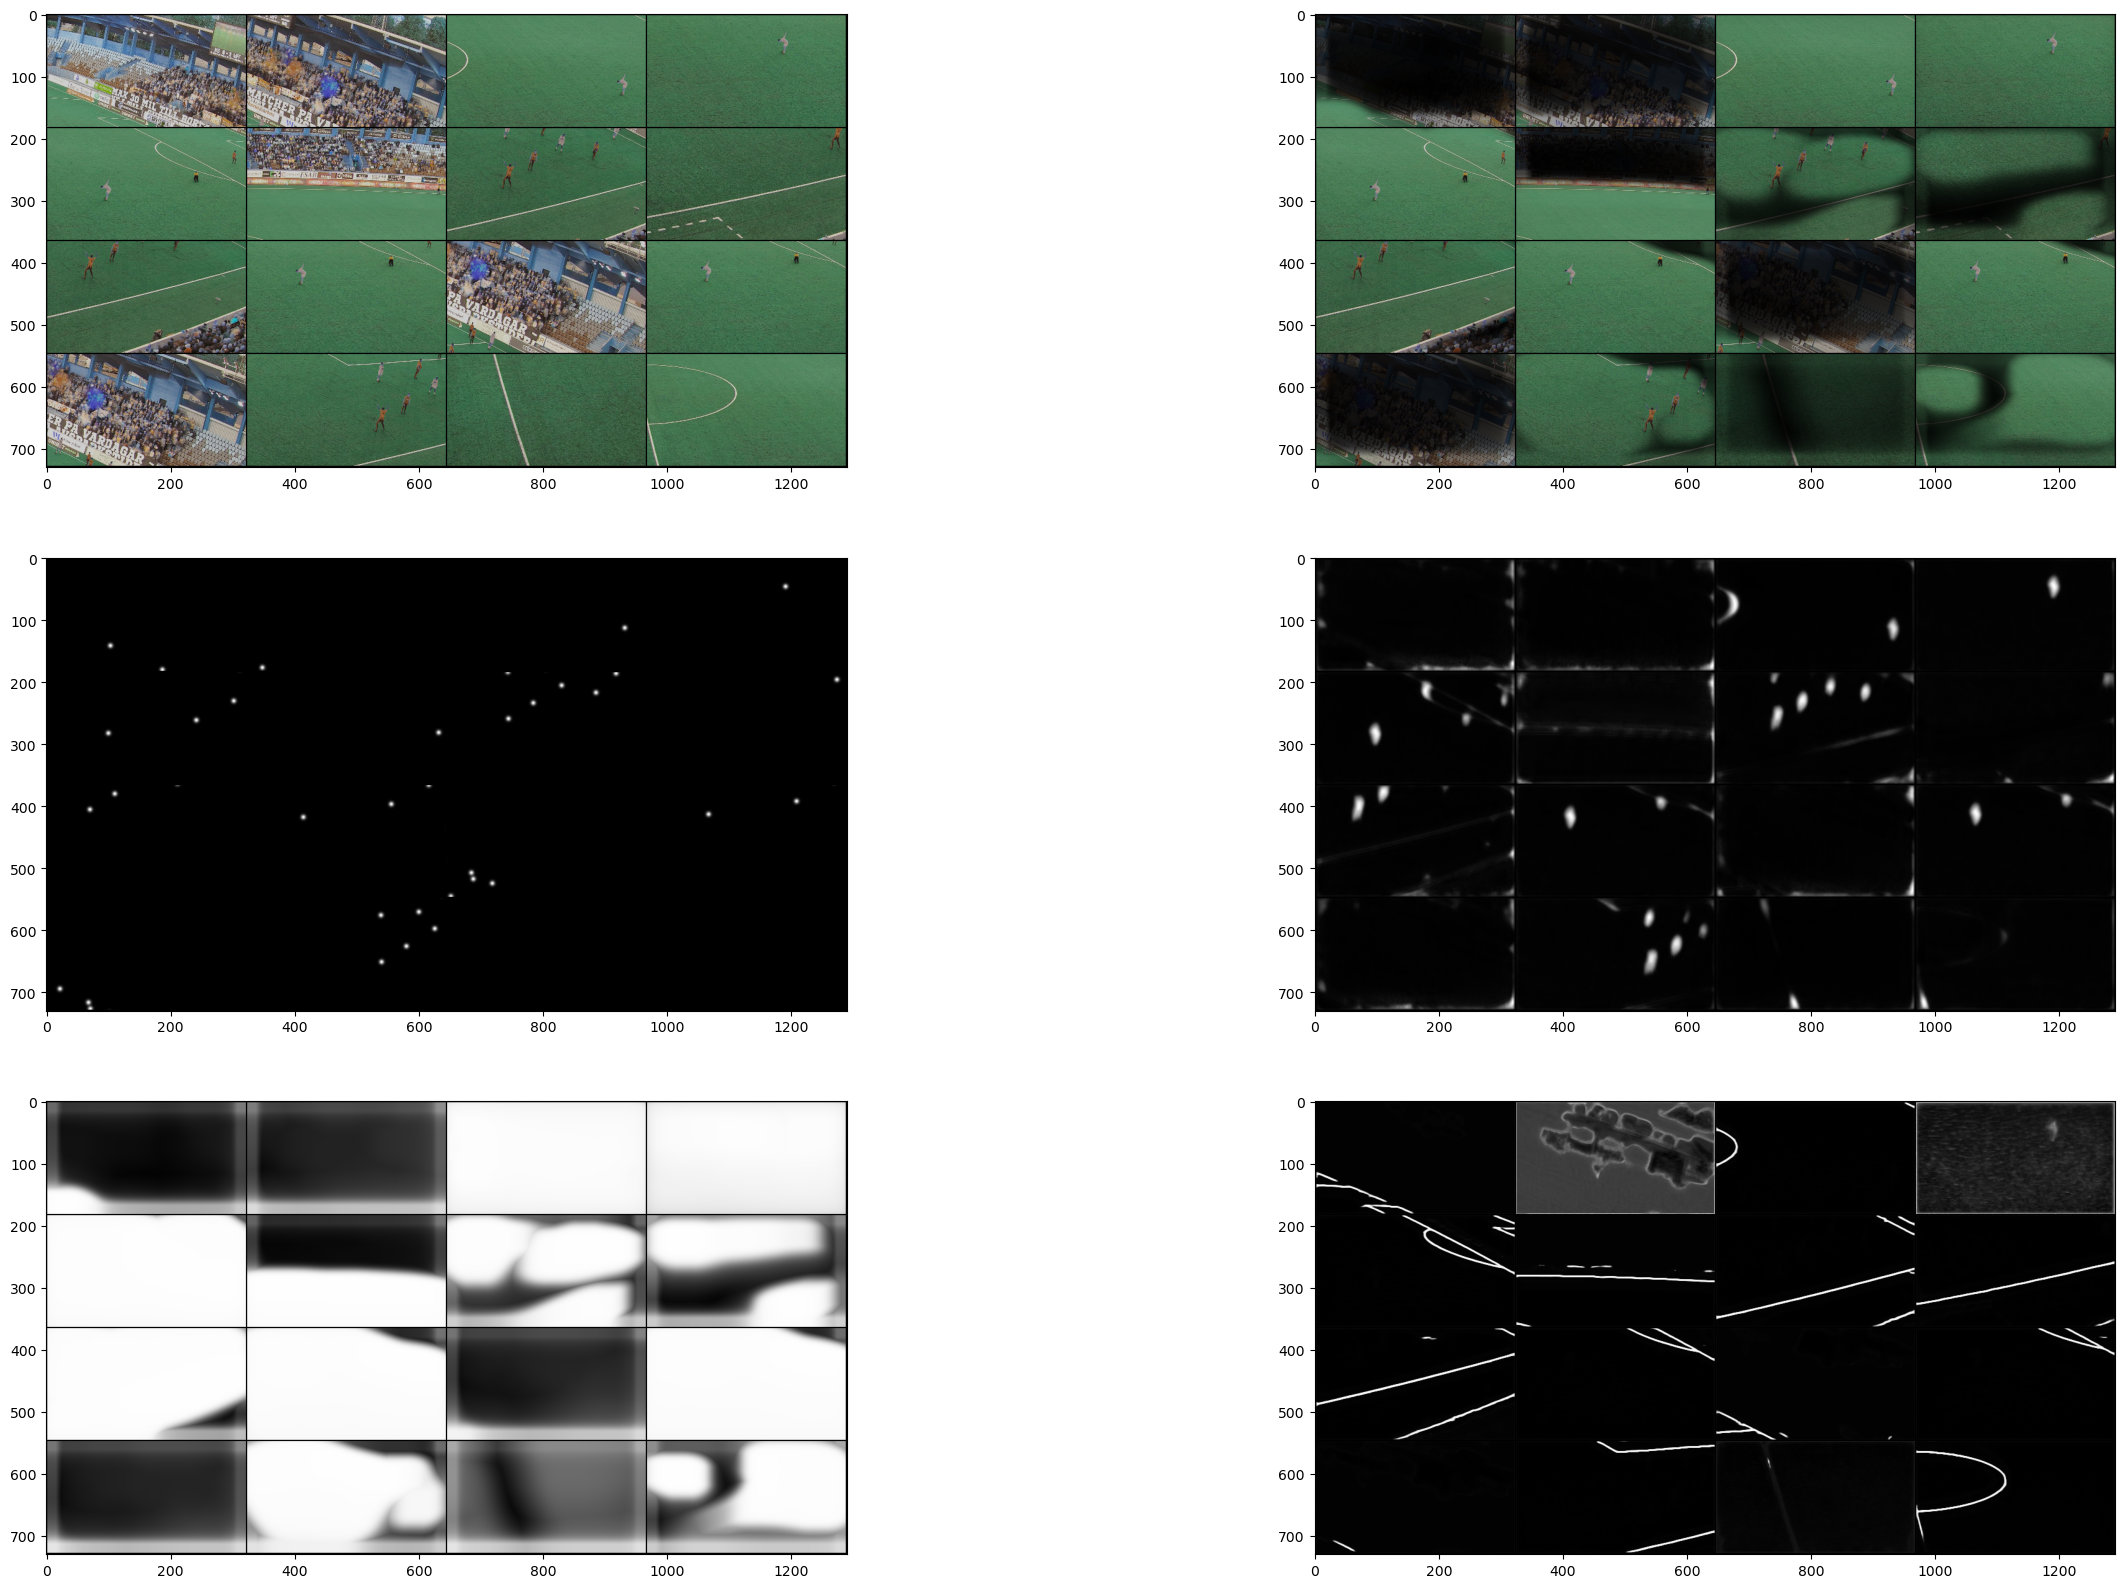

In [10]:
def gridify(img):
    return make_grid(img, nrow=4).permute((1, 2, 0)).cpu()

img_ = gridify(img)
img_cover_ = gridify(cover_blur * img)
heatmap_ = gridify(heatmap)
cover_blur_ = gridify(cover_blur)
segments_ = gridify(segments)
mask_ = gridify(mask)

print('Output for display:')
print('img.shape  = ', img_.shape)
print('heatmap.shape = ', heatmap_.shape)
print('cover.shape = ', cover_blur_.shape)
print('segments_.shape = ', segments_.shape)
print('mask.shape = ', mask_.shape)

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(30,20))
ax.flat[0].imshow(img_, cmap='gray')
ax.flat[1].imshow(img_cover_, cmap='gray')
ax.flat[2].imshow(mask_, cmap='gray')
ax.flat[3].imshow(heatmap_, cmap='gray')
ax.flat[4].imshow(cover_blur_, cmap='gray')
ax.flat[5].imshow(segments_, cmap='gray')
fig.show()

## GMM in Pytorch

In [133]:
from pipelines.coordinate_regression.gmml import GMML

import gc
gc.collect()
torch.mps.empty_cache()

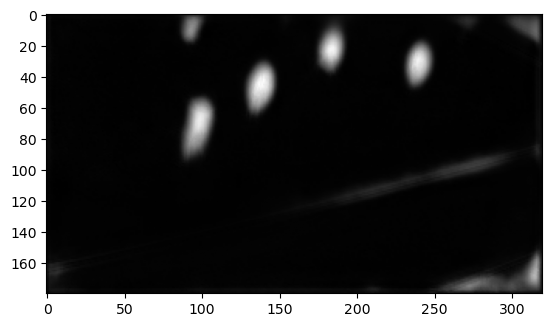

In [134]:
IDX = 6
plt.imshow(heatmap[IDX].detach().cpu().permute((1, 2, 0)), cmap='gray')
plt.show()

torch.Size([16, 1, 180, 320])


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_32428/1384052910.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  heatmap_trimmed = torch.tensor(heatmap)


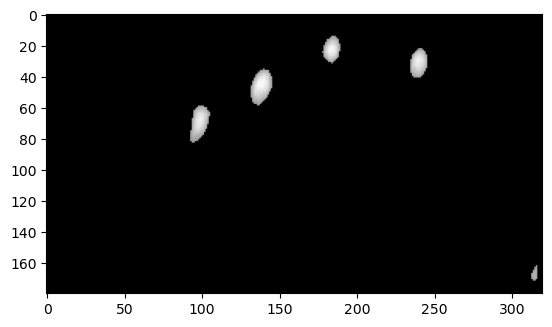

In [254]:
THRESHOLD = 0.6
heatmap_trimmed = torch.tensor(heatmap)
heatmap_trimmed[heatmap_trimmed <= THRESHOLD] = 0
print(heatmap_trimmed.shape)

plt.imshow(heatmap_trimmed[IDX].detach().cpu().permute((1, 2, 0)), cmap='gray')
plt.show()

In [255]:
import gc
gc.collect()
torch.mps.empty_cache()

In [256]:
heatmap_trimmed.flatten(start_dim=1, end_dim=3).shape

torch.Size([16, 57600])

In [257]:
probs, idxs = torch.topk(heatmap_trimmed.flatten(start_dim=1, end_dim=3), k=3000, dim=1)
probs = probs / probs.sum(axis=-1).view(16, -1)
print(probs.shape)

idxs = torch.stack(torch.unravel_index(idxs, heatmap.shape[1:]), axis=2)
print(idxs.shape)

torch.Size([16, 3000])
torch.Size([16, 3000, 3])


In [258]:
print(probs)
print(probs.sum(axis=-1))

tensor([[0.0151, 0.0150, 0.0149,  ..., 0.0000, 0.0000, 0.0000],
        [0.0141, 0.0141, 0.0140,  ..., 0.0000, 0.0000, 0.0000],
        [0.0027, 0.0027, 0.0027,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0021, 0.0021, 0.0021,  ..., 0.0000, 0.0000, 0.0000],
        [0.0091, 0.0090, 0.0090,  ..., 0.0000, 0.0000, 0.0000],
        [0.0087, 0.0087, 0.0087,  ..., 0.0000, 0.0000, 0.0000]], device='mps:0')
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='mps:0')


In [259]:
import gc
gc.collect()
torch.mps.empty_cache()

NUM_SAMPLES_PER_BATCH = 100
samples = torch.multinomial(probs, num_samples=NUM_SAMPLES_PER_BATCH, replacement=True)

batch_samples = torch.arange(idxs.shape[0]).view(-1, 1).expand(-1, samples.shape[1])
pts = idxs[batch_samples, samples]
print(pts.shape)

torch.Size([16, 100, 3])


In [260]:
pts[IDX].device

device(type='mps', index=0)

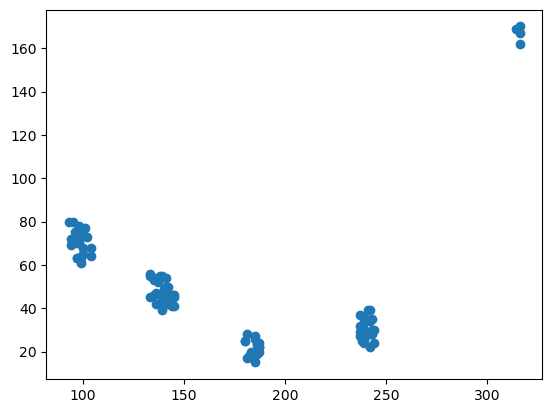

In [261]:
ys, xs = pts[IDX][:, 1], pts[IDX][:, 2]
ys = ys.cpu()
xs = xs.cpu()

plt.scatter(xs, ys)
plt.show()

In [262]:
# [TODO]: Extract top_k pixel indices --> Generate heatmaps with the indices as centres.

In [263]:
pts[IDX][:, 1]

tensor([ 22,  28,  41,  74,  72,  22,  46,  36,  53,  55,  39, 167,  22,  50,  74,  50,  68,  45,  20,  47,  46,  68,  63,  26,  63,  43, 169,  69,  33,  47,  63,  55,  80,  43,  30,  65,  73,  24,  43,  64,  70,  18,  55,  72,  61,  26,  35,  32,  25,  46,  28,  46,  39,  41,  27,  75,  27,  24,  77,  37,  42,  15,
         30,  42,  42,  49,  46,  35,  25,  70,  44, 162,  45,  78,  54,  34,  71,  50,  23,  43,  54,  52, 170,  24,  27,  28,  56,  76,  26,  30,  25,  20,  19,  29,  45,  39,  20,  80,  24,  17], device='mps:0')

In [390]:
def _generate_batched_gmm_heatmap(shape, centers, sigmas):
    """
    Args:
        shape: (H, W)
        centers: [B, N, 2] -> (x, y)
        sigmas: [B, N, 2] -> (sx, sy)
    Returns:
        heatmap: [B, H, W]
    """
    B, N, _ = centers.shape
    H, W = shape
    device = centers.device

    # 1. Create coordinate grids [H, W]
    y_range = torch.arange(H, dtype=torch.float32, device=device)
    x_range = torch.arange(W, dtype=torch.float32, device=device)
    y_grid, x_grid = torch.meshgrid(y_range, x_range, indexing='ij')

    # 2. Reshape grids for broadcasting: [1, 1, H, W]
    x_grid = x_grid.view(1, 1, H, W)
    y_grid = y_grid.view(1, 1, H, W)

    # 3. Reshape centers and sigmas: [B, N, 1, 1]
    cx = centers[:, :, 1].view(B, N, 1, 1)
    cy = centers[:, :, 0].view(B, N, 1, 1)
    sx = sigmas[:, :, 0].view(B, N, 1, 1)
    sy = sigmas[:, :, 1].view(B, N, 1, 1)

    # 4. Compute exponent: [B, N, H, W]
    # Equation: -((x-cx)^2 / (2*sx^2) + (y-cy)^2 / (2*sy^2))
    eps = 1e-8
    exponent = -( ((x_grid - cx)**2 / (2 * sx**2 + eps)) + 
                  ((y_grid - cy)**2 / (2 * sy**2 + eps)) )
    
    # 5. Generate Blobs
    blobs = torch.exp(exponent)

    # 6. Normalize each blob to max 1: [B, N, H, W]
    # We find max over the (H, W) dimensions for each individual blob
    blob_max = blobs.view(B, N, -1).max(dim=-1)[0].view(B, N, 1, 1)
    blobs = blobs / (blob_max + eps)

    # 7. Sum across N (number of components) and clamp
    # Summing turns [B, N, H, W] -> [B, H, W]
    heatmap = torch.sum(blobs, dim=1)
    return torch.clamp(heatmap, 0, 1)

In [ ]:
def _generate_batched_gmm_heatmap_from_heatmap(heatmap):
    B, C, H, W = heatmap.shape
    sigmas = heatmap.view(B, -1)

    TOP_K = 200
    sigma_top, idxs = torch.topk(sigmas, k=TOP_K, dim=1)

    ys, xs = torch.unravel_index(idxs, (H, W))
    centers = torch.stack([ys, xs], dim=-1)
    sigmas = sigma_top.unsqueeze(-1).expand(B, -1, 2)

    return _generate_batched_gmm_heatmap((H, W), centers, sigmas)

In [426]:
heatmap_gaussian = _generate_batched_gmm_heatmap_from_heatmap(heatmap_trimmed)
heatmap_gaussian.shape

torch.Size([16, 180, 320])

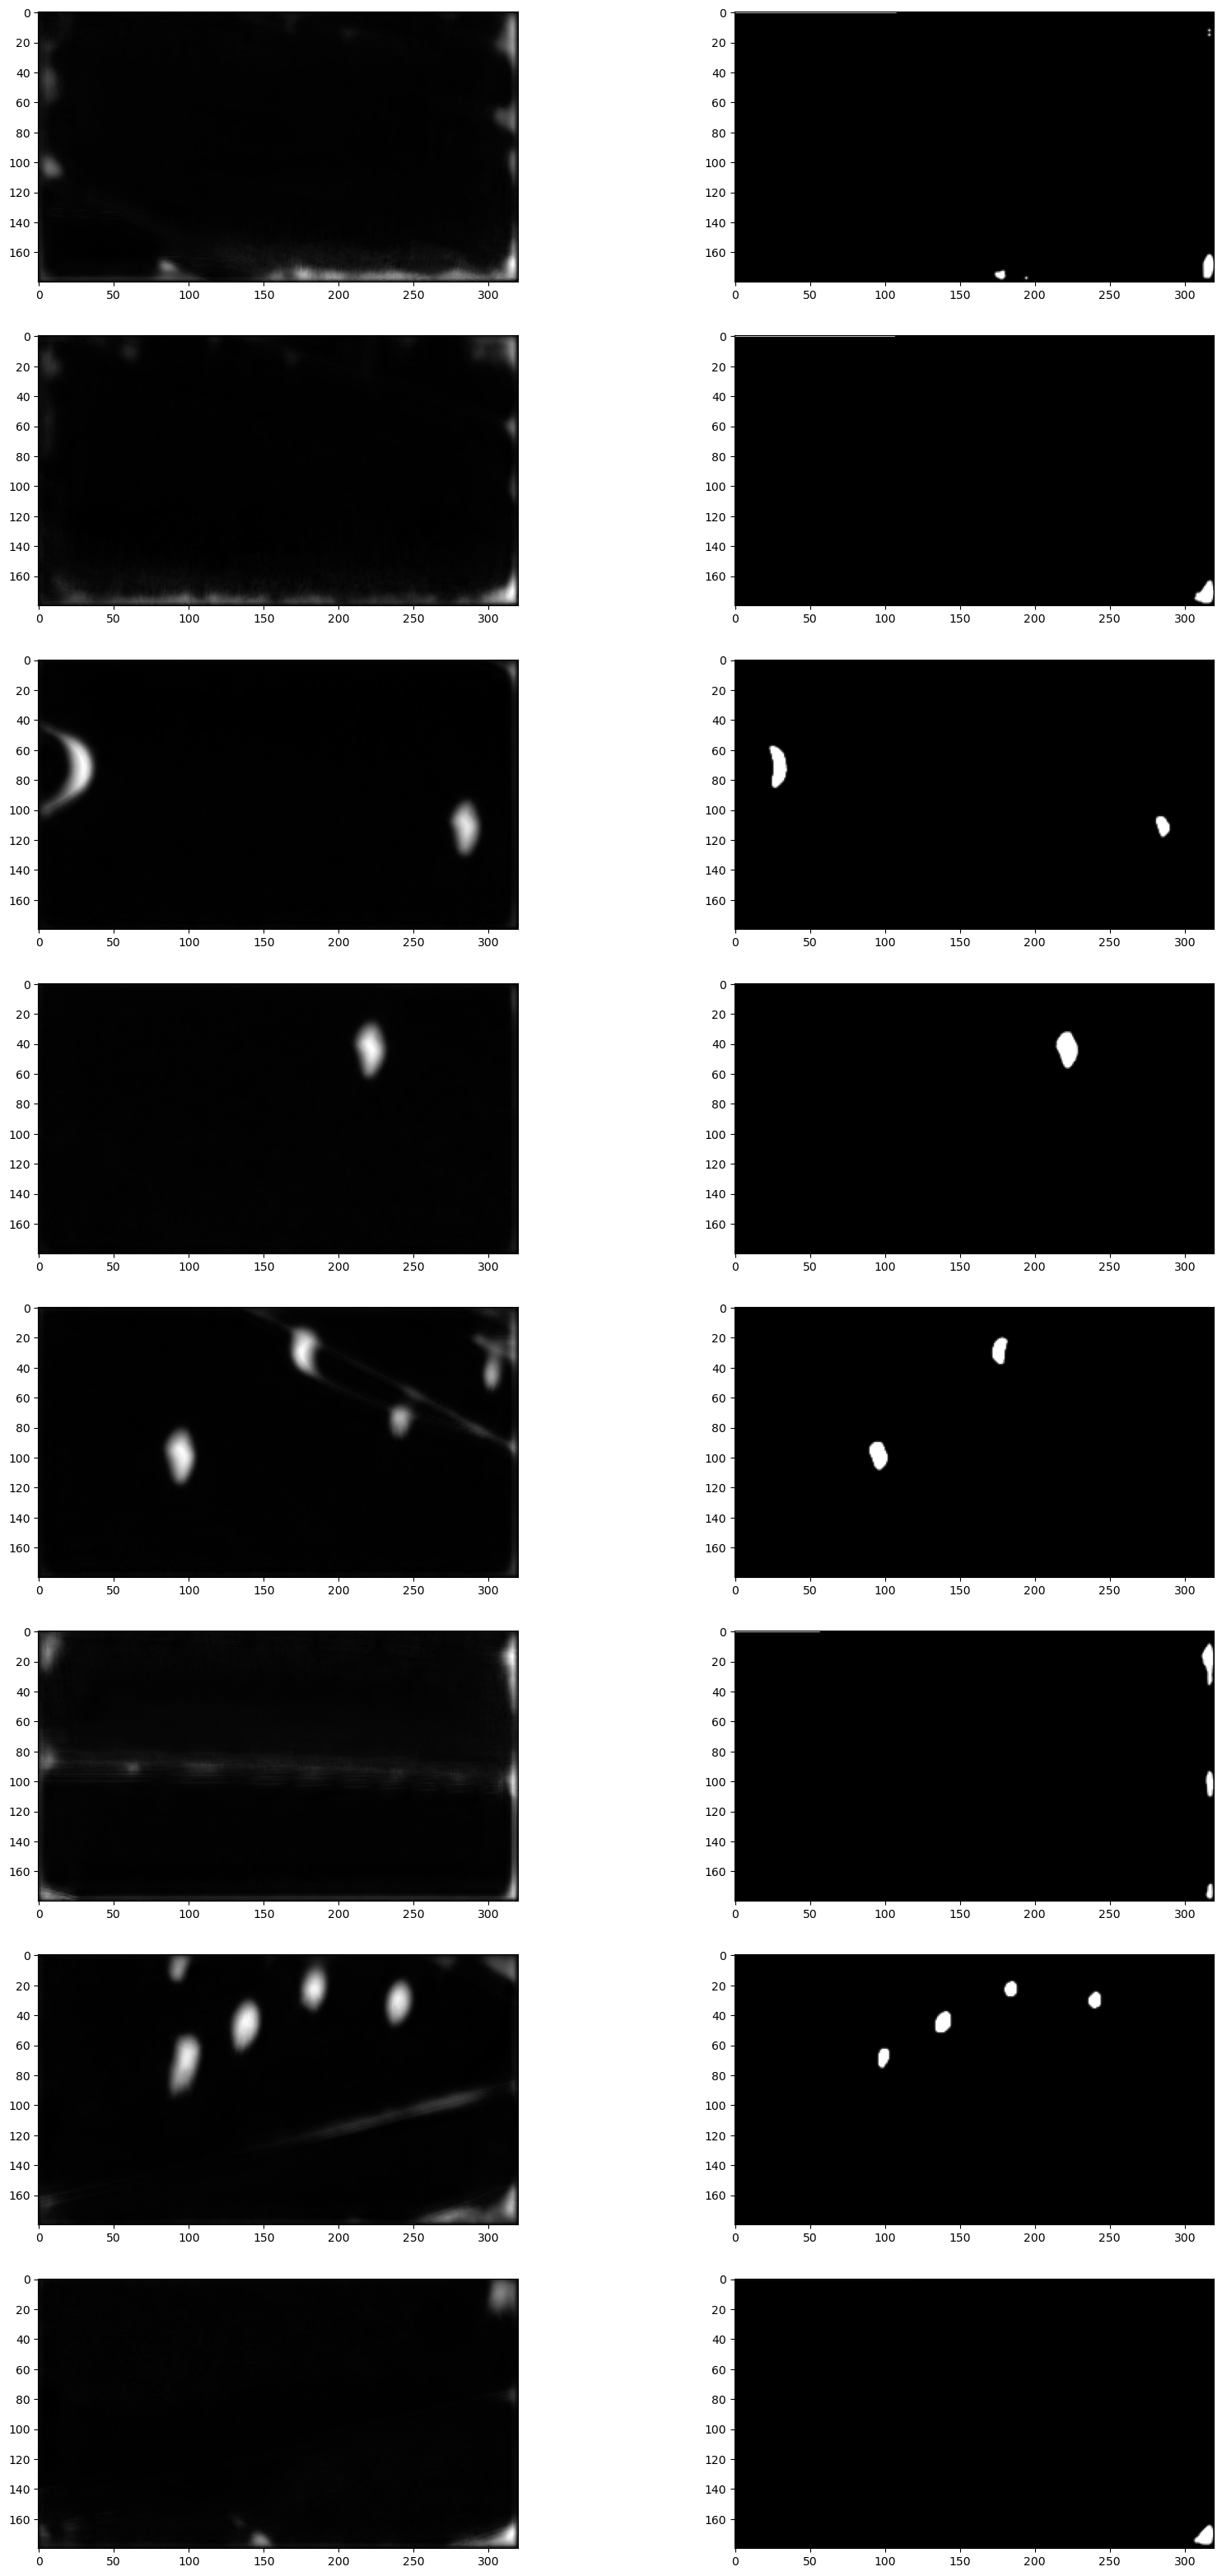

In [427]:
fig, ax = plt.subplots(nrows=8, ncols=2, figsize=(20, 40))

for idx in range(8):
    ax[idx, 0].imshow(heatmap[idx][0].detach().cpu(), cmap='gray')
    ax[idx, 1].imshow(heatmap_gaussian[idx].cpu(), cmap='gray')

plt.show()